First we will import the Libraries For the Data Cleaning and Preprocessing

In [291]:
import pandas as pd

In [292]:
df=pd.read_csv('customer_churn.csv')
df.sample(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5312,9564-KCLHR,Male,0,No,No,1,Yes,No,DSL,No,...,No,Yes,No,No,Month-to-month,No,Mailed check,51.25,51.25,Yes
3479,8229-TNIQA,Female,0,No,No,4,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,45.30,196.95,Yes
1687,8332-OSJDW,Male,0,Yes,Yes,12,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,26.40,314.95,No
5655,5666-MBJPT,Male,0,No,No,65,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),25.10,1725,No


In [293]:
# for safety purpose we will store out df in one place

new_df = df.copy()

# now we will be using only new_df for the operations

In [294]:
new_df.drop('customerID',axis=1,inplace=True)  # here we have removed the customer id because we dont want that

In [295]:
new_df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [296]:
new_df.dtypes  # from here we have observed that Total Charges are in the object it should be in int or float in (numerical)

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [297]:
# now our job is to convert that total charges to the actual form 

new_df['TotalCharges'].unique()  # they are represented in array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'] in single quote

new_df['TotalCharges']=pd.to_numeric(new_df['TotalCharges'],errors='coerce') # this is the line where we are converting the total cahrges to teh actual form using to_numeric
new_df = new_df.dropna()

In [298]:
new_df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [320]:
new_df.isnull().sum()

gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
MultipleLines                              0
OnlineSecurity                             0
OnlineBackup                               0
DeviceProtection                           0
TechSupport                                0
StreamingTV                                0
StreamingMovies                            0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
Churn                                      0
InternetService_0                          0
InternetService_DSL                        0
InternetService_Fiber optic                0
Contract_Month-to-month                    0
Contract_One year                          0
Contract_T

In [299]:
tenure_yes=df[df['Churn']=='Yes'].tenure # here we are checking when churn is yes what is their tenure 
tenure_no=df[df['Churn']=='No'].tenure # ly here also

In [300]:
import matplotlib.pyplot as plt

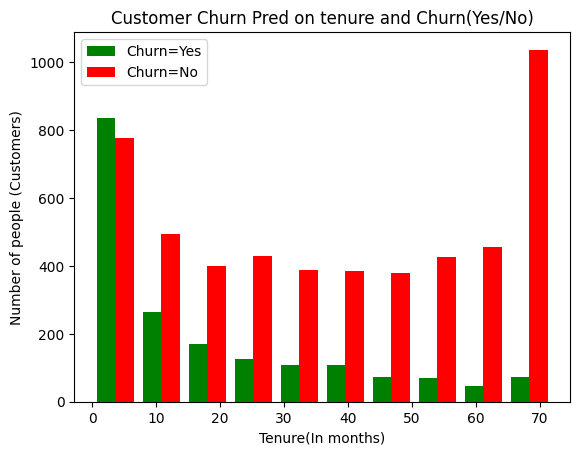

In [301]:
plt.xlabel('Tenure(In months)')
plt.ylabel('Number of people (Customers)')
plt.title('Customer Churn Pred on tenure and Churn(Yes/No)')
plt.hist([tenure_yes,tenure_no],color=['Green','Red'],label=['Churn=Yes','Churn=No'])

plt.legend()
plt.savefig('Customer Churn Pred on tenure and Churn.jpg')

plt.show()

# from this we can know that when their is high tenure approx(70 months) the people are leaving


In [302]:
new_df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [303]:
# now we will go through the uniquevalues

def print_unique_values(data):
    for col in data:
        print(f"{col} columns has this unique values {new_df[col].unique()}")

In [304]:
print_unique_values(new_df)

gender columns has this unique values ['Female' 'Male']
SeniorCitizen columns has this unique values [0 1]
Partner columns has this unique values ['Yes' 'No']
Dependents columns has this unique values ['No' 'Yes']
tenure columns has this unique values [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService columns has this unique values ['No' 'Yes']
MultipleLines columns has this unique values ['No phone service' 'No' 'Yes']
InternetService columns has this unique values ['DSL' 'Fiber optic' 'No']
OnlineSecurity columns has this unique values ['No' 'Yes' 'No internet service']
OnlineBackup columns has this unique values ['Yes' 'No' 'No internet service']
DeviceProtection columns has this unique values ['No' 'Yes' 'No internet service']
TechSupport columns has this unique values ['No' 'Yes' 'No internet service']

In [305]:
new_df.replace('No internet service','No',inplace=True)
new_df.replace('No phone service','No',inplace=True)

In [306]:
print_unique_values(new_df) # now here we have cleaned the data that is looking similar

gender columns has this unique values ['Female' 'Male']
SeniorCitizen columns has this unique values [0 1]
Partner columns has this unique values ['Yes' 'No']
Dependents columns has this unique values ['No' 'Yes']
tenure columns has this unique values [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService columns has this unique values ['No' 'Yes']
MultipleLines columns has this unique values ['No' 'Yes']
InternetService columns has this unique values ['DSL' 'Fiber optic' 'No']
OnlineSecurity columns has this unique values ['No' 'Yes']
OnlineBackup columns has this unique values ['Yes' 'No']
DeviceProtection columns has this unique values ['No' 'Yes']
TechSupport columns has this unique values ['No' 'Yes']
StreamingTV columns has this unique values ['No' 'Yes']
StreamingMovies columns has this unique values ['N

In [307]:
# now here we can see that their are yes and no so machine cannot unerstand the yes or no we will convert that to
# yes = 1 , no = 0

new_df.replace({
    "Yes":1,
    "No":0
},inplace=True)

new_df.replace({
    'Male':0,
    'Female':1
},inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_30848\199545639.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df.replace({
C:\Users\admin\AppData\Local\Temp\ipykernel_30848\199545639.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df.replace({


In [308]:
# now we will check the dtypes

new_df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [309]:
for col in new_df:
    if new_df[col].dtypes=='object':
        print(f"{col} columns has this unique values {new_df[col].unique()}")

InternetService columns has this unique values ['DSL' 'Fiber optic' 0]
Contract columns has this unique values ['Month-to-month' 'One year' 'Two year']
PaymentMethod columns has this unique values ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [310]:
new_df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [311]:
# by using onehotencoding we should convert this into the zeros and 1's

cols_todo_onehotencoding=['InternetService','Contract','PaymentMethod']
new_df = pd.get_dummies(new_df, columns=cols_todo_onehotencoding)

In [312]:
new_df.dtypes # successfully we have converted the more variables to numbers using one hot encoding using get_dummies

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_0                             bool
InternetService_DSL                           bool
InternetService_Fiber optic    

In [313]:
new_df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_0,InternetService_DSL,InternetService_Fiber optic,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1668,1,0,0,0,45,1,1,1,1,1,...,False,False,True,True,False,False,False,False,True,False
5724,0,0,0,0,1,1,0,0,0,0,...,False,False,True,True,False,False,False,False,False,True
2795,1,1,0,0,9,1,1,0,0,0,...,False,False,True,True,False,False,False,False,True,False
4439,0,0,1,1,28,1,0,0,0,0,...,True,False,False,False,False,True,False,True,False,False
1942,0,0,0,0,46,1,0,0,0,0,...,True,False,False,False,False,True,False,True,False,False


In [314]:
# so successfuly converting the data into 0's and 1's we have left with tenure i.e it has values from 1 to some extinct so we should bring that 
# in bettwween zeros and 1's

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_to_scale = ['tenure','MonthlyCharges','TotalCharges']

new_df[cols_to_scale] = scaler.fit_transform(new_df[cols_to_scale])

In [315]:
new_df['MonthlyCharges'].sample(9)

2633    0.814925
1743    0.065672
2102    0.619900
5857    0.696517
6865    0.470149
2866    0.660199
99      0.798507
5561    0.023881
3867    0.549751
Name: MonthlyCharges, dtype: float64

In [316]:
new_df.sample(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_0,InternetService_DSL,InternetService_Fiber optic,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2083,1,0,0,0,0.000000,1,0,0,0,0,...,True,False,False,True,False,False,False,False,False,True
4799,1,0,1,1,0.126761,1,0,0,0,0,...,True,False,False,True,False,False,True,False,False,False
1400,0,0,0,1,0.028169,1,0,0,0,0,...,True,False,False,True,False,False,False,False,False,True


In [317]:
# now we should train_test_split the data

from sklearn.model_selection import train_test_split

X = new_df.drop('Churn', axis=1) # except churn all 
y = new_df['Churn'] # only churn

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [318]:
X_train.shape

(5625, 26)

In [319]:
X_test.shape

(1407, 26)

Now building the model using artificial neural network

In [321]:
import tensorflow as tf
from tensorflow import keras

In [381]:
model = keras.Sequential([
    keras.layers.Dense(128, input_shape=(26,), activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16,activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [382]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [383]:
model.fit(X_train, y_train, epochs=100)

Epoch 1/100


176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7781 - loss: 0.4530
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8060 - loss: 0.4164
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8076 - loss: 0.4130
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8103 - loss: 0.4079
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8105 - loss: 0.4034
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8123 - loss: 0.4009
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8149 - loss: 0.3954
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8162 - loss: 0.3924
Epoch 9/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8190 - loss: 0.3896
Epoch 10/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8228 - loss: 0.3837
Epoch 11/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8233 - loss: 0.3789
Epoch 12/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [384]:
y_pred = model.predict(X_test)

y_pred

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


array([[4.9894356e-11],
       [9.8737866e-02],
       [9.5496041e-01],
       ...,
       [9.0144677e-06],
       [9.2874716e-06],
       [5.4087908e-13]], dtype=float32)

In [385]:
y_pred = (model.predict(X_test) > 0.5).astype(int)
y_pred[:10]

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0]])

In [386]:
for i in range(100):
    print("Actual:", y_test.iloc[i], "Predicted:", y_pred[i])

Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 1 Predicted: [1]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [1]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 1 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 1 Predicted: [1]
Actual: 0 Predicted: [0]
Actual: 1 Predicted: [0]
Actual: 1 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [1]
Actual: 0 Predicted: [1]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 1 Predicted: [1]
Actual: 1 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 1 Predicted: [1]
Actual: 1 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [1]
Actual: 0 Predicted: [1]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]


In [387]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [389]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[866, 167],
       [188, 186]], dtype=int64)

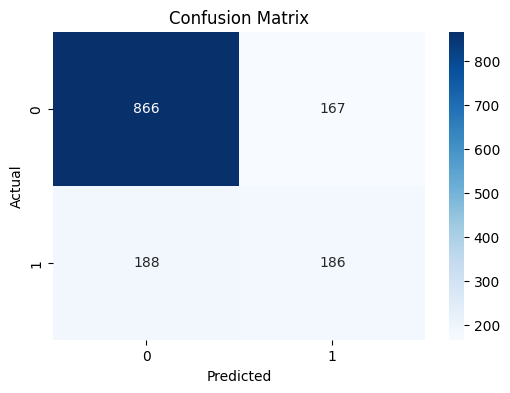

In [390]:
plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [391]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7476901208244492


In [392]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1033
           1       0.53      0.50      0.51       374

    accuracy                           0.75      1407
   macro avg       0.67      0.67      0.67      1407
weighted avg       0.74      0.75      0.75      1407

